# Lecture 3: Overfitting, Generalization, Unsupervised & Self-Supervised Learning
### *Democratizing Machine Learning with Aayush*

---

Welcome to the **Lecture 3** coding companion!  
This notebook covers the fundamental concepts taught in Lecture 3 with detailed mathematical explanations and runnable Python & PyTorch demonstrations.

**Table of Contents:**
1. **Empirical Risk vs. Population Risk & Generalization Gap**
2. **Train / Validation / Test Splits & Hyperparameter Tuning**
3. **No Free Lunch Theorem & Inductive Bias**
4. **Unsupervised Learning — Density Estimation & Clustering**
5. **Discovering Latent Factors of Variation — PPCA & VAEs**
6. **Self-Supervised Learning (SSL) — Masked Representation Learning**
7. **Evaluating Unsupervised Models & Downstream Sample Efficiency**
8. **Primer on Reinforcement Learning (RL)**

> **Tip:** Keep your pen and paper ready to work through derivations alongside the executable code!


## 0. Setup — Install & Import Libraries


In [ ]:
!pip install numpy matplotlib seaborn scikit-learn torch scipy --quiet


In [ ]:
#Import libraries, Start here...
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm as sp_norm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import torch, torch.nn as nn, torch.optim as optim

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
torch.manual_seed(42)
print("All libraries loaded successfully")
##End code here.


All libraries loaded successfully


---
## 1. Overfitting, Population Risk & Generalization Gap

### 1.1 Empirical Risk vs. Population Risk

When we train a machine learning model, we minimise the loss over the available training samples $\mathcal{D}_{\text{train}} = \{(\mathbf{x}_n, y_n)\}_{n=1}^N$.
This is called **Empirical Risk**:

$$\mathcal{R}_{\text{emp}}(\theta) = \frac{1}{N} \sum_{n=1}^{N} \ell\left(y_n,\ f(\mathbf{x}_n;\, \theta)\right)$$

However, our ultimate goal is **not** just to perform well on the training data. We want the model to perform well on future unseen data drawn from the true underlying distribution $P^*(\mathbf{x}, y)$.
This expected loss is called **Population Risk**:

$$\mathcal{R}_{\text{pop}}(\theta) = \mathbb{E}_{(\mathbf{x}, y) \sim P^*}\left[ \ell\left(y,\ f(\mathbf{x};\, \theta)\right) \right] = \iint \ell\left(y,\ f(\mathbf{x};\, \theta)\right) P^*(\mathbf{x}, y)\, d\mathbf{x}\, dy$$

### 1.2 Generalization Gap

The difference between the population risk and empirical risk is the **Generalization Gap**:

$$\text{GenGap}(\theta) = \mathcal{R}_{\text{pop}}(\theta) - \mathcal{R}_{\text{emp}}(\theta)$$

- **Underfitting:** High $\mathcal{R}_{\text{emp}}(\theta)$ and high $\mathcal{R}_{\text{pop}}(\theta)$. Small generalization gap, but overall poor performance.
- **Overfitting:** Low $\mathcal{R}_{\text{emp}}(\theta)$ (model memorises training noise), but high $\mathcal{R}_{\text{pop}}(\theta)$. **Large generalization gap**.
- **Good Fit:** Low $\mathcal{R}_{\text{emp}}(\theta)$ and low $\mathcal{R}_{\text{pop}}(\theta)$ with a small generalization gap.


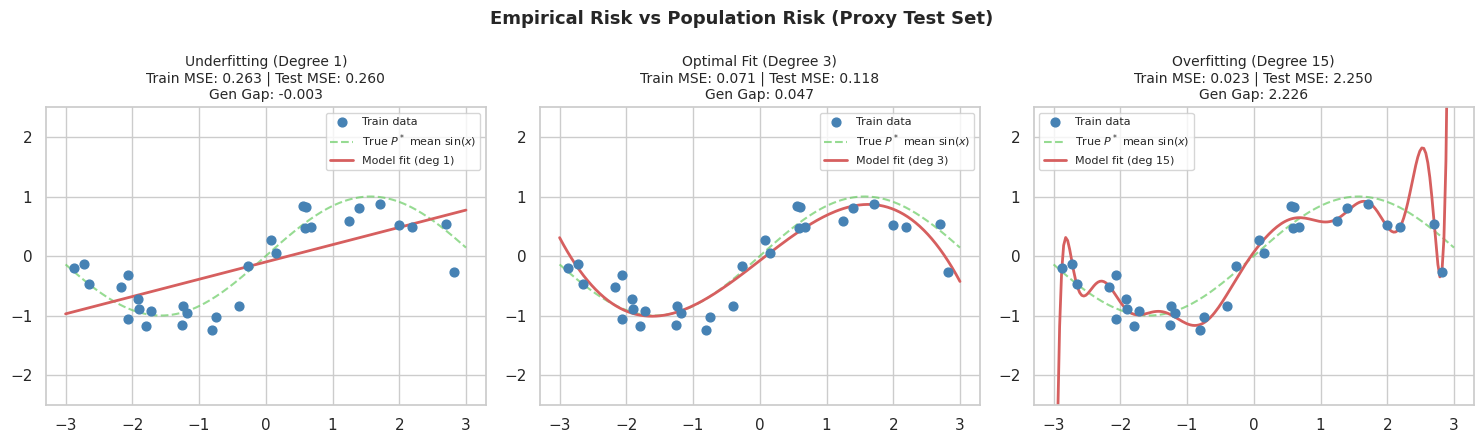

In [ ]:
# ── Demonstration of Underfitting, Overfitting, and Generalization Gap ──
#Start Code here..
np.random.seed(42)
N_samples = 30
X_true = np.linspace(-3,3,200).reshape(-1,1) #creating a contiguous range for plotting the true function
y_true_func = lambda x : np.sin(x) #defines the true underlying function (sine wave)

#Sample training data from P* with noise
X_tr = np.random.uniform(-3,3,N_samples).reshape(-1,1) #Randomly sample X values for training
y_tr = y_true_func(X_tr).ravel() + 0.3 * np.random.randn(N_samples) #generate y values with added Gaussian noise.

#Sample a large test set representing P*
#This test set serve as a proxy for the true population distribution P*
X_te = np.random.uniform(-3,3,1000).reshape(-1,1)
y_te = y_true_func(X_te).ravel() + 0.3 * np.random.randn(1000)

#End here

degrees = [1, 3, 15]
titles = ['Underfitting (Degree 1)', 'Optimal Fit (Degree 3)', 'Overfitting (Degree 15)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, deg, title in zip(axes, degrees, titles):
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X_tr, y_tr)

    tr_mse = mean_squared_error(y_tr, pipe.predict(X_tr))
    te_mse = mean_squared_error(y_te, pipe.predict(X_te))
    gen_gap = te_mse - tr_mse

    ax.scatter(X_tr, y_tr, color='steelblue', label='Train data', s=40, zorder=5)
    ax.plot(X_true, y_true_func(X_true), 'g--', label=r'True $P^*$ mean $\sin(x)$', alpha=0.7)
    ax.plot(X_true, pipe.predict(X_true), 'r-', linewidth=2, label=f'Model fit (deg {deg})')
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(title + f'\nTrain MSE: {tr_mse:.3f} | Test MSE: {te_mse:.3f}\nGen Gap: {gen_gap:.3f}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(r'Empirical Risk vs Population Risk (Proxy Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 2. Proxy for $P^*$: Train / Validation / Test Splits

Since the true distribution $P^*$ is unknown in real life, we cannot evaluate $\mathcal{R}_{\text{pop}}(\theta)$ directly.
Instead, we partition our available dataset $\mathcal{D}$ into three disjoint sets:

1. **Training Set ($\mathcal{D}_{\text{train}}$):** Used to optimize model parameters $\theta$.
2. **Validation Set ($\mathcal{D}_{\text{val}}$):** Used for **model selection** and hyperparameter tuning (e.g., choosing polynomial degree $d$ or regularization strength $\lambda$).
3. **Test Set ($\mathcal{D}_{\text{test}}$):** Held-out proxy for $P^*$ to measure final generalization performance. Must **never** be used during training or hyperparameter tuning!


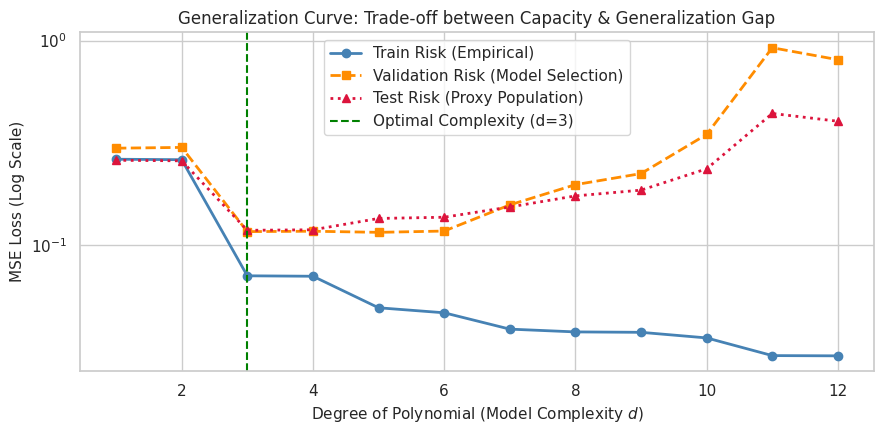

Optimal degree selected by validation set: d = 5


In [ ]:
# ── Generalization curve over Model Complexity ──
#Start code here..
degs = np.arange(1, 13) #Range of polynomial degrees to test (model complexity)
tr_errors, val_errors, te_errors = [], [], []

#Generate a separate validation set (distinct from train and test )
X_val = np.random.uniform(-3,3,200).reshape(-1,1)
y_val = y_true_func(X_val).ravel() + 0.3 * np.random.randn(200)

#loop through each polynomial degree to evaluate the model performance
for d in degs:
    pipe = make_pipeline(PolynomialFeatures(d), LinearRegression()) #creates the model pipeline
    pipe.fit(X_tr, y_tr) #Train the model on the training data
    #Calculate and store the mean squared error for each set
    tr_errors.append(mean_squared_error(y_tr, pipe.predict(X_tr)))
    val_errors.append(mean_squared_error(y_val, pipe.predict(X_val)))
    te_errors.append(mean_squared_error(y_te, pipe.predict(X_te)))

#End code here..

plt.figure(figsize=(9, 4.5))
plt.plot(degs, tr_errors, 'o-', color='steelblue', label='Train Risk (Empirical)', linewidth=2)
plt.plot(degs, val_errors, 's--', color='darkorange', label='Validation Risk (Model Selection)', linewidth=2)
plt.plot(degs, te_errors, '^:', color='crimson', label='Test Risk (Proxy Population)', linewidth=2)
plt.yscale('log')
plt.xlabel('Degree of Polynomial (Model Complexity $d$)', fontsize=11)
plt.ylabel('MSE Loss (Log Scale)', fontsize=11)
plt.title('Generalization Curve: Trade-off between Capacity & Generalization Gap', fontsize=12)
plt.axvline(3, color='green', linestyle='--', label='Optimal Complexity (d=3)')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Optimal degree selected by validation set: d = {degs[np.argmin(val_errors)]}')


---
## 3. The No Free Lunch (NFL) Theorem & Inductive Bias

### 3.1 What does NFL state?
The **No Free Lunch Theorem** mathematically states that averaged over **all possible data-generating distributions**, no single learning algorithm outperforms any other (even random guessing!).

### 3.2 Inductive Bias
Since no algorithm works universally for all problems, every successful machine learning model relies on **Inductive Bias** — a set of assumptions about the domain structure incorporated into the algorithm:
- **Linear Regression:** Assumes output is a linear combination of features.
- **Convolutional Networks (CNNs):** Assumes spatial locality and translation invariance.
- **Recurrent / Attention Networks:** Assumes sequential structure and context relevance.


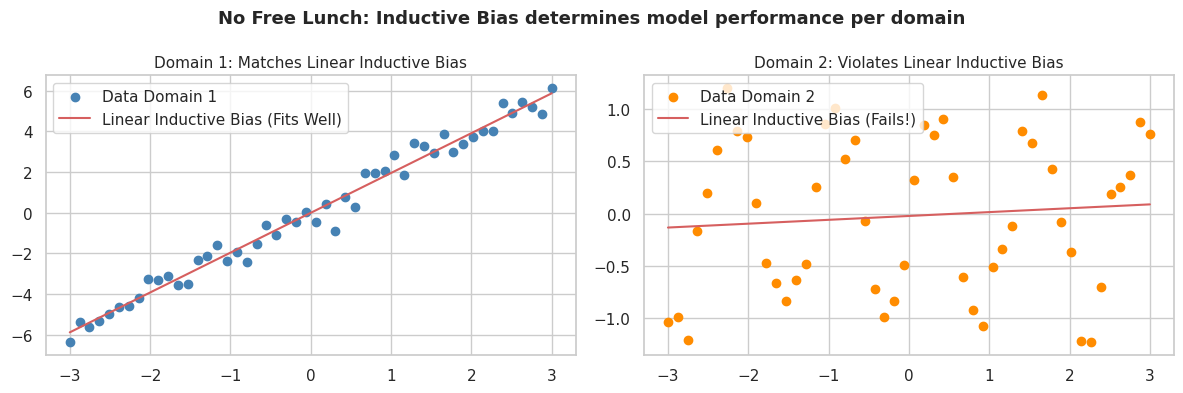

In [ ]:
# ── Demonstration of Inductive Bias ──
# Model A (Linear Model) vs Model B (RBF Network / Decision Tree) on two different domains

#Start code here...
#Domain 1 : Linear Relationship
X_d1 = np.linspace(-3,3,50).reshape(-1,1)
y_d1 = 2 * X_d1.ravel() + 0.5 * np.random.randn(50)

#Domain 2 : Periodic / Oscillatory relationship
X_d2 = np.linspace(-3,3,50).reshape(-1,1)
y_d2 = np.sin(5*X_d2.ravel()) + 0.2 * np.random.randn(50) #data with a non-linear, oscillatory trend

fig, axes = plt.subplots(1,2,figsize=(12,4)) #create a figure with two subplots

#Fit the linearmodel on both domains
lin_d1 = LinearRegression().fit(X_d1, y_d1) #train the linear model on Domain 1
lin_d2 = LinearRegression().fit(X_d2, y_d2) #train the linear model on Domain 2
#End code here..

axes[0].scatter(X_d1, y_d1, color='steelblue', label='Data Domain 1')
axes[0].plot(X_d1, lin_d1.predict(X_d1), 'r-', label='Linear Inductive Bias (Fits Well)')
axes[0].set_title('Domain 1: Matches Linear Inductive Bias', fontsize=11)
axes[0].legend()

axes[1].scatter(X_d2, y_d2, color='darkorange', label='Data Domain 2')
axes[1].plot(X_d2, lin_d2.predict(X_d2), 'r-', label='Linear Inductive Bias (Fails!)')
axes[1].set_title('Domain 2: Violates Linear Inductive Bias', fontsize=11)
axes[1].legend()

plt.suptitle('No Free Lunch: Inductive Bias determines model performance per domain', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Unsupervised Learning — Density Estimation & Clustering

### 4.1 Supervised vs Unsupervised
- **Supervised:** Learn conditional mapping $p(y \mid \mathbf{x};\ \theta)$ from labeled pairs $(\mathbf{x}_n, y_n)$. Provides only a few bits of label supervision per example.
- **Unsupervised:** Learn unconditional density $p(\mathbf{x};\ \theta)$ from unlabelled samples $\{\mathbf{x}_n\}_{n=1}^N$.

As noted by Prof. Geoffrey Hinton, the human brain (with $\sim 10^{14}$ synapses living for $\sim 10^9$ seconds) receives massive high-dimensional sensory inputs ($10^5$ bits/sec), whereas explicit labels ("this is a dog") provide very few bits. Unsupervised learning forces the model to explain and structure high-dimensional input space.

### 4.2 Clustering Example (K-Means)
Clustering partitions unlabeled data into $K$ clusters by finding centroids $\boldsymbol{\mu}_k$ that minimise total intra-cluster distance.


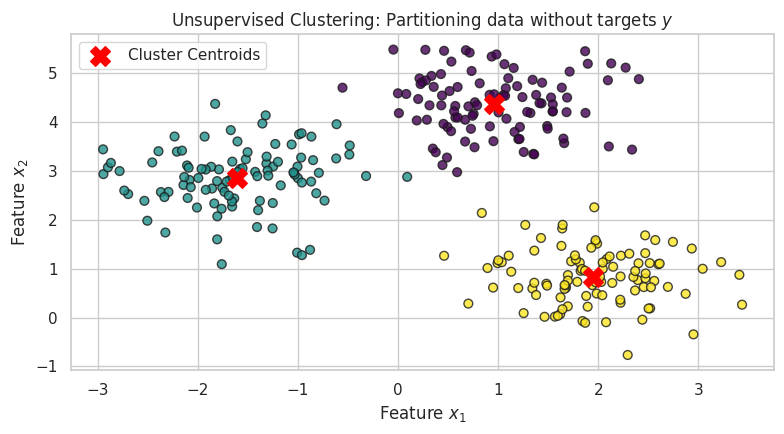

In [ ]:
# ── Unsupervised Learning: Clustering (K-Means) ──
#Start code here..
from sklearn.datasets import make_blobs

#Generate synthetic 2d data with 3 distinct clusters.
X_cluster, y_true_cluster = make_blobs(n_samples=300, centers=3, cluster_std = 0.60, random_state = 0)
#X_cluster contains the feature data, y_true_cluster contains the true (hidden) cluster labels

kmeans = KMeans(n_clusters=3, random_state = 42, n_init = 10) #initialize kmeans with 3 clusters and a random seed
y_kmeans = kmeans.fit_predict(X_cluster) #we fit kmeans to the data and predict cluster assignments for each point
##End here..

plt.figure(figsize=(8, 4.5))
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=y_kmeans, s=40, cmap='viridis', alpha=0.8, edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Cluster Centroids')
plt.title('Unsupervised Clustering: Partitioning data without targets $y$', fontsize=12)
plt.xlabel('Feature $x_1$')
plt.ylabel('Feature $x_2$')
plt.legend()
plt.tight_layout()
plt.show()


---
## 5. Discovering Latent Factors of Variation — PPCA & VAEs

### 5.1 High-Dimensional Observations $\mathbf{x}$ & Low-Dimensional Latents $\mathbf{z}$
Observed high-dimensional data $\mathbf{x}_n \in \mathbb{R}^D$ is often generated by a low-dimensional underlying hidden state $\mathbf{z}_n \in \mathbb{R}^K$ (where $K \ll D$):

$$\mathbf{z}_n \sim p(\mathbf{z}), \qquad \mathbf{x}_n \sim p(\mathbf{x} \mid \mathbf{z}_n;\ \theta)$$

### 5.2 Linear Latent Model: Probabilistic PCA / Factor Analysis
When the generative mapping from $\mathbf{z}$ to $\mathbf{x}$ is linear:

$$p(\mathbf{z}_n) = \mathcal{N}(\mathbf{0},\ \mathbf{I}_K)$$
$$p(\mathbf{x}_n \mid \mathbf{z}_n;\ \mathbf{W}, \boldsymbol{\mu}, \sigma^2) = \mathcal{N}\!\left(\mathbf{W}\mathbf{z}_n + \boldsymbol{\mu},\ \sigma^2 \mathbf{I}_D\right)$$

### 5.3 Non-Linear Latent Model: Variational Autoencoder (VAE)
When the decoder mapping is a non-linear neural network $f_\theta(\mathbf{z})$:

$$p(\mathbf{x}_n \mid \mathbf{z}_n;\ \theta) = \mathcal{N}\!\left(f_\theta(\mathbf{z}_n),\ \sigma^2 \mathbf{I}_D\right)$$

Since exact posterior inference $p(\mathbf{z} \mid \mathbf{x})$ becomes intractable due to non-linearity, VAEs introduce a learned encoder $q_\phi(\mathbf{z} \mid \mathbf{x})$ to approximate it.


VAE trained successfully! Final Loss : 654.1362


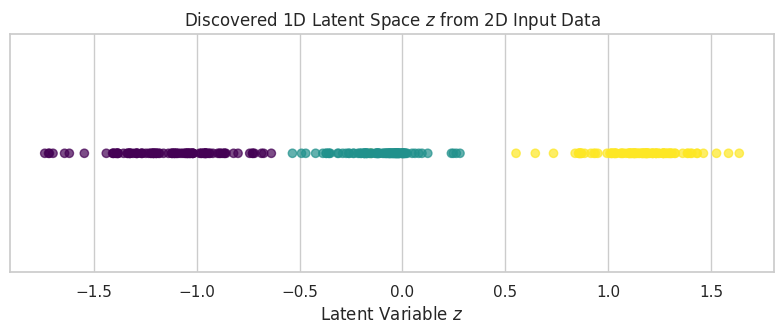

In [ ]:
class VAE(nn.Module):
  def __init__(self, input_dim=2, latent_dim=1):
    super().__init__()
    #Encoder q_phi(z|x) : This part maps the input data 'x' to a latent space 'z'
    self.encoder = nn.Sequential(
        nn.Linear(input_dim, 32), #first linear layer : input dim (e.g 2D) to 32 neurons
        nn.ReLU() #activation function: Rectified Linear Unit
    )
    self.fc_mu = nn.Linear(32, latent_dim) #linear layer to output the mean (mu) of the latent distribution
    self.fc_logvar = nn.Linear(32, latent_dim) #linear layer to output the log-variance of the latent distribution

    #Decoder p_theta(x|z) : This part reconstructs the input data 'x' from the latent space 'z'
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 32), #First linear layer: latent_dim (eg 1D) to 32 neurons
        nn.ReLU(), #activation function
        nn.Linear(32, input_dim) #output linear layer: 32 neurons back to input_dim(reconstructed x)
    )

  #The reparameterization trick is crucial for VAEs to allow backpropation through the sampling step
  #It samples 'z' from a distribution defined by mean mu and variance log var
  def reparameterize(self, mu, logvar):
      std = torch.exp(0.5 * logvar) #calculates the standard deviation from the log-variance
      eps = torch.randn_like(std) #here we are sampling random noise from a standard normal distribution (epsilon)
      return mu + eps * std #combine mu, epsilon, and std to get the latent sample 'z'

  def forward(self, x):
      h = self.encoder(x) #pass the input 'x' through the encoder
      mu, logvar = self.fc_mu(h), self.fc_logvar(h) #calculate the mean and the log-variance from the encoder output
      z = self.reparameterize(mu, logvar) #apply reparameterization trick to get the latent 'z'
      x_recon = self.decoder(z) #we pass the latent 'z' through the decoder to reconstruct 'x'
      return x_recon, mu, logvar

  #Loss function for VAE : combines reconstruction loss (how well x is reconstructed) and KL divergence (how close latent distribution is
  #to a prior)
  def vae_loss(x_recon, x, mu, logvar):
      recon_loss = nn.functional.mse_loss(x_recon, x, reduction='sum') #reconstruction loss,
      kl_div = -0.5 * torch.sum(1 + logvar -mu.pow(2) - logvar.exp())
      return recon_loss + kl_div #total VAE loss

#Train VAE on synthetic 2d data(the clusters generated earlier)
X_tensor = torch.from_numpy(X_cluster).float() #convert the numpy array to pytorch tensor and cast to float32
vae = VAE(input_dim=2, latent_dim=1) #initialize the vae with 2d input and 1d latent space
optimizer = optim.Adam(vae.parameters(), lr=1e-2) #using adam optimizer for training

#Training loop
for epoch in range(500):
    optimizer.zero_grad() #we first clear the gradient sfrom previous iteration
    x_recon, mu, logvar = vae(X_tensor) #forward pass: get reconsructed x, mu and logvar
    loss = VAE.vae_loss(x_recon, X_tensor, mu, logvar) #calculates the VAE loss
    loss.backward() #backpropagation: computing gradients
    optimizer.step() #updating the model parameters

print(f"VAE trained successfully! Final Loss : {loss.item():.4f}") #we print the final loss

#Now we encode data to a 1d latent space z for visualization
with torch.no_grad() : #disable gradient calcuation for inference
  _, latents_mu, _ = vae(X_tensor) #get the latent means (mu) for each data point


##End code here..

plt.figure(figsize=(8, 3.5))
plt.scatter(latents_mu.numpy(), np.zeros_like(latents_mu.numpy()), c=y_kmeans, cmap='viridis', alpha=0.7)
plt.title('Discovered 1D Latent Space $z$ from 2D Input Data', fontsize=12)
plt.xlabel('Latent Variable $z$')
plt.yticks([])
plt.tight_layout()
plt.show()

---
## 6. Self-Supervised Learning (SSL) — Masked Predictions

### 6.1 Creating Proxy Supervised Tasks
In **Self-Supervised Learning**, we avoid the hard problem of exact latent posterior inference. Instead, we generate **proxy supervised tasks** directly from unlabelled data $\mathbf{x}$:
- **Masked Language Modeling (e.g. BERT):** Mask out input tokens $\mathbf{x}_{\text{masked}}$ and predict them using contextual information $\mathbf{x}_{\text{context}}$:

$$\hat{\mathbf{x}}_{\text{masked}} = f(\mathbf{x}_{\text{context}};\ \theta)$$

Example text: `"The [MASK] sails on the sea"` $\rightarrow$ Predict target `"ship"`.


In [ ]:
# ── Masked Feature Prediction Task (Tabular/Feature SSL) ──
##Start code here..
np.random.seed(42)
N_ssl = 500
#we create 4 features wher f4 is correlated with f1 and f2
f1 = np.random.randn(N_ssl)
f2 = np.random.randn(N_ssl)
f3 = np.random.randn(N_ssl)
f4 = 2.0 * f1 - 1.5 * f2 + 0.1 * np.random.randn(N_ssl)
X_raw = np.column_stack([f1, f2, f3, f4]) #combine features into a single dataset

#mask out the 4th feature 4 and predict it from features 1,2,3
X_context = X_raw[:,:3] #use features f1, f2, f3 as the context (input to the model)
y_masked_target = X_raw[:,3] #we use feature f4 as the target to be predicted (the mask feature)

ssl_model = LinearRegression().fit(X_context, y_masked_target) #train a linear regression model to predict f4 from f1, f2, f3
y_ssl_pred = ssl_model.predict(X_context) #we are makaing predictions using the trained model


print('Learned weights to reconstruct feature 4 from context features 1,2,3')
print(f' w1 (true 2.0) : {ssl_model.coef_[0]:.4f}')
print(f' w2 (true -1.5) : {ssl_model.coef_[1]:.4f}')
print(f' w3 (true 0.1) : {ssl_model.coef_[2]:.4f}')
print('bY predicting masked features, the model learns key underlying data correlations without external labels!')
##End code here..

Learned weights to reconstruct feature 4 from context features 1,2,3
 w1 (true 2.0) : 2.0062
 w2 (true -1.5) : -1.5016
 w3 (true 0.1) : -0.0017
bY predicting masked features, the model learns key underlying data correlations without external labels!


---
## 7. Evaluating Unsupervised Models & Downstream Sample Efficiency

### 7.1 Density Estimation Evaluation (Log-Likelihood)
We evaluate an unsupervised model using negative log-likelihood on unseen test data:

$$\mathcal{L}_{\text{NLL}}(\theta) = -\frac{1}{N_{\text{test}}} \sum_{n=1}^{N_{\text{test}}} \log p(\mathbf{x}_n \mid \theta)$$

However, density estimation in high dimensions is notoriously difficult.

### 7.2 Downstream Evaluation & Sample Efficiency
An alternative standard metric is **downstream performance**:
1. Train an unsupervised model on unlabelled data to extract features $\mathbf{z} = f_{\text{repr}}(\mathbf{x})$.
2. Train a linear classifier on top of $\mathbf{z}$ using a **very small labelled dataset**.
3. High **sample efficiency** means achieving strong performance with minimal labelled samples!


In [ ]:
##Start code here..
#Sample efficiency comparison: raw features vs learned representations:
#generate 10D dataset where class label depends on latent 2d pca subspace
X_highdim, y_labels = make_blobs(n_samples=1000, n_features = 10, centers=2, random_state=42)
#xX_highdim is a 10-dimensional dataset, where y_labels are the true class labels

#1. Unsupervised representation learning via pCA
pca = PCA(n_components = 2).fit(X_highdim) #Apply PCA to reduce dimensionality from 10D to 2D
X_repr = pca.transform(X_highdim) #we transform the high-dimensional data into its 2D principal components

#2. Compare downstream linear classifier performance with limited labelled samples (N=10)
N_limited = 10 #Define a very small number of labelled samples for training

#Split the data for raw features and their corresponding labels
X_tr_raw, X_te_raw, y_tr_labels, y_te_labels = train_test_split(X_highdim, y_labels, train_size = N_limited, random_state = 42)

# Split the representations, ensuring they correspond to the same samples as raw features and labels
X_tr_repr, X_te_repr, _, _ = train_test_split(X_repr, y_labels, train_size = N_limited, random_state = 42)

#Train linear classifiers on the limited labelled data
clf_raw = LinearRegression().fit(X_tr_raw, y_tr_labels) #classifier trained on raw 10D features
clf_repr = LinearRegression().fit(X_tr_repr, y_tr_labels) #classifer trained on learned 2D representations

#Now we calculate the accuracy on the test set
#we convert the regression output to binary predictions for accuracy calculations
acc_raw = accuracy_score(y_te_labels, (clf_raw.predict(X_te_raw) > 0.5).astype(int))
acc_repr = accuracy_score(y_te_labels, (clf_repr.predict(X_te_repr) > 0.5).astype(int))

print(f"Downstream classification accuracy with only N = {N_limited}labelled examples:")
print(f' 1. Model trained on raw features: {acc_raw:.4f}')
print(f' 2. Model trained on learned representations: {acc_repr:.4f}')





#End code here..

Downstream classification accuracy with only N = 10labelled examples:
 1. Model trained on raw features: 0.9990
 2. Model trained on learned representations: 1.0000


---
## 8. Primer on Reinforcement Learning (RL)

### 8.1 The RL Loop
Unlike supervised learning (learning with a teacher) or unsupervised learning (learning from data structure), **Reinforcement Learning** involves an **Agent** interacting with an **Environment**:
- At time step $t$, the agent receives a state/percept $s_t \in \mathcal{S}$.
- The agent selects an action $a_t \sim \pi(a \mid s_t)$ according to its policy $\pi$.
- The environment transitions to $s_{t+1}$ and emits a scalar reward $r_t \in \mathbb{R}$.

$$\text{Percept } s_t \quad \longrightarrow \quad \text{Action } a_t \quad \longrightarrow \quad \text{Reward } r_t$$

### 8.2 Critic vs Teacher
- **Supervised Learning:** Teacher provides the *exact correct action/label* $y$.
- **Reinforcement Learning:** Critic provides a *scalar reward signal* evaluating how good or bad the action was (often delayed and sparse).


In [ ]:
#Start code here..
#Simple Multi-Armed Bandit Simulation
#the first thing is to define the multiarmed bandit environment
class MultiArmedBandit:
    def __init__(self, true_means):
      self.true_means = true_means #the true average reward for each arm(Action)
      self.k = len(true_means) #number of arms (actions) available

    def pull(self, action):
      #when an arm is pulled it returns a reward with a gaussian noise around its true mean
      return self.true_means[action] + np.random.randn() #adds random noise from a standard normal distribution

#Initialize a bandit problem with 3 arms and their true expected rewards
bandit = MultiArmedBandit(true_means = [0.2,1.5,-0.5]) #arm 0, arm 1 and arm2 with different means
q_estimates = np.zeros(3) #initialze Q-value estimates (estimated value of each arm) to zero
action_counts = np.zeros(3) #keep track of how many times each arm has been pulled
epsilon = 0.1 #epsilon-greedy exploration rate : 10% chance to explore, 90% to exploit

rewards_history = [] #list to store all the collected rewards
#we simulate the agent interacting with the environment for 500 time steps
for t in range(500):
  #epsilon greedy policy decision
  if np.random.rand() < epsilon:
    action = np.random.choice(3) #we explore or randomly choose to pull an arm
  else:
    action = np.argmax(q_estimates) #exploit : choose the arm with the highest current Q-value estimates

  reward = bandit.pull(action) #the agent performs the chosen action and receives a reward
  rewards_history.append(reward) #records the reward.

  #We do an incremental update of Q-estimates (the average of rewards for that action)
  action_counts[action] += 1 #we increment the count for the chosen action
  #we update the Q-estimates for the chosen action using a running average formula
  q_estimates[action] += (reward - q_estimates[action]) /action_counts[action]

print('Multi armed bandit(RL agent) training complete')
print(f' True arm reward means : {bandit.true_means}')
print(f' Estimated arm reward means (Learned Q-value estimates): {q_estimates.round(3)}')
print(f' Action counts : {action_counts}')
print(f' The RL agent identifies arm {np.argmax(q_estimates)+1} as the best/optimal arm through trial and feedback!') #states the
#optimal arm found by the agent









#End code here..

Multi armed bandit(RL agent) training complete
 True arm reward means : [0.2, 1.5, -0.5]
 Estimated arm reward means (Learned Q-value estimates): [ 0.336  1.408 -0.595]
 Action counts : [ 38. 438.  24.]
 The RL agent identifies arm 2 as the best/optimal arm through trial and feedback!


---
## 9. Lecture 3 Summary

| Concept | Key Mathematical / Logical Takeaway |
|---|---|
| **Empirical Risk** | $\mathcal{R}_{\text{emp}}(\theta) = \frac{1}{N} \sum_n \ell(y_n, f(\mathbf{x}_n; \theta))$ — loss on training data |
| **Population Risk** | $\mathcal{R}_{\text{pop}}(\theta) = \mathbb{E}_{(\mathbf{x},y) \sim P^*} [\ell(y, f(\mathbf{x}; \theta))]$ — expected loss on true distribution |
| **Generalization Gap** | $\text{GenGap}(\theta) = \mathcal{R}_{\text{pop}}(\theta) - \mathcal{R}_{\text{emp}}(\theta)$ |
| **Test / Val Splits** | Test set acts as proxy for $P^*$; Val set used for model selection |
| **No Free Lunch (NFL)** | No universal best model; inductive bias is required per domain |
| **Unsupervised Learning** | Models $p(\mathbf{x})$; forces explanation of high-dimensional inputs |
| **Latent Factor Models** | High-dim $\mathbf{x}$ generated from low-dim $\mathbf{z}$ (PPCA: linear, VAE: non-linear) |
| **Self-Supervised Learning** | Creates proxy tasks (e.g. masked prediction) to learn representations |
| **Sample Efficiency** | Downstream task accuracy using few labelled samples |
| **Reinforcement Learning** | Agent learns via trial and error from a scalar reward (critic) |

---
**Next Lecture:** Datasets, Document Encoding & TF-IDF Schemes!
